# Universe B Overlap Analysis

This notebook diagnoses whether Universe B's high panel missingness comes from poor overlap between market lifetimes or genuinely sparse market data. It also evaluates the requested overlap-constrained universes B-25, B-40, and B-50 before any persistent-homology work.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "overlap_analysis.py").exists():
            return candidate
        nested = candidate / "polymarket_topology"
        if (nested / "src" / "overlap_analysis.py").exists():
            return nested
    raise FileNotFoundError("Could not locate polymarket_topology project root")

ROOT = find_project_root(Path.cwd().resolve())
sys.path.append(str(ROOT / "src"))

from overlap_analysis import run_analysis

PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "notebooks" / "figures" / "overlap_analysis"
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
plt.style.use("default")
warnings.filterwarnings("ignore", category=RuntimeWarning)

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Run Reproducible Analysis

In [2]:
analysis = run_analysis(
    candidate_markets_path=PROCESSED / "candidate_universe_markets.parquet",
    prices_path=PROCESSED / "prices_long.parquet",
    universe_b_panel_path=PROCESSED / "universe_b_macro_crypto_panel.parquet",
    output_dir=PROCESSED,
)

lifetimes = analysis["lifetimes"]
overlap = analysis["overlap"]
missingness = analysis["missingness"]
candidates = analysis["candidates"]
overlap_stats = analysis["overlap_stats"]

print("lifetimes", lifetimes.shape)
print("overlap", overlap.shape)
print("candidate summary", candidates.shape)
print(missingness)

lifetimes (171, 18)
overlap (171, 171)
candidate summary (4, 20)
{'total_cells': 2473344, 'observed_filled_cells': 532979, 'raw_observed_cells': 530587, 'missing_cells': 1940365, 'overall_missingness': 0.7845107676085493, 'structural_missing_cells': 1915462, 'data_missing_cells': 24903, 'active_raw_missing_cells': 27295, 'structural_missing_fraction_of_all': 0.7744422126481395, 'data_missing_fraction_of_all': 0.010068554960409874, 'structural_share_of_missing': 0.9871658167406647, 'data_share_of_missing': 0.012834183259335228, 'raw_sparsity_within_active': 0.04892611699248228, 'filled_missing_within_active': 0.04463847193492531}


## Part 1: Market Lifetime Analysis

In [3]:
lifetime_cols = [
    "market_id", "broad_domain", "broad_family", "resolved_outcome", "start_date", "end_date", "close_date",
    "active_duration_hours", "first_observed_timestamp", "last_observed_timestamp", "observed_hours", "average_pairwise_overlap", "question"
]
display(lifetimes[lifetime_cols].sort_values("active_duration_hours", ascending=False).head(25))

lifetime_summary = lifetimes.groupby(["broad_domain", "broad_family", "resolved_outcome"], dropna=False).agg(
    markets=("market_id", "nunique"),
    median_active_days=("active_duration_hours", lambda s: s.median() / 24),
    median_observed_hours=("observed_hours", "median"),
    avg_overlap=("average_pairwise_overlap", "mean"),
).reset_index().sort_values(["broad_domain", "broad_family", "resolved_outcome"])
display(lifetime_summary)

,market_id,broad_domain,broad_family,resolved_outcome,start_date,end_date,close_date,active_duration_hours,first_observed_timestamp,last_observed_timestamp,observed_hours,average_pairwise_overlap,question
17,572469,macro,macro_fed_rates,Yes,2025-08-05 17:28:15.516000+00:00,2026-12-31 00:00:00+00:00,2026-03-04 19:25:43+00:00,12294.529023,2025-08-05 18:00:00+00:00,2026-03-04 19:00:00+00:00,4992,0.011625,Will Trump nominate Kevin Warsh as the next Fe...
33,572470,macro,macro_fed_rates,No,2025-08-05 17:28:17.427441+00:00,2026-12-31 00:00:00+00:00,2026-03-04 19:57:05+00:00,12294.528492,2025-08-05 18:00:00+00:00,2026-03-04 19:00:00+00:00,5053,0.011625,Will Trump nominate Kevin Hassett as the next ...
47,572472,macro,macro_fed_rates,No,2025-08-05 17:28:19.462000+00:00,2026-12-31 00:00:00+00:00,2026-03-04 20:09:07+00:00,12294.527927,2025-08-05 18:00:00+00:00,2026-03-04 20:00:00+00:00,5056,0.011625,Will Trump nominate Bill Pulte as the next Fed...
39,572471,macro,macro_fed_rates,No,2025-08-05 17:28:19.714000+00:00,2026-12-31 00:00:00+00:00,2026-03-04 19:56:09+00:00,12294.527857,2025-08-05 18:00:00+00:00,2026-03-04 19:00:00+00:00,5012,0.011625,Will Trump nominate Christopher Waller as the ...
6,572473,macro,macro_fed_rates,No,2025-08-05 17:28:21.437992+00:00,2026-12-31 00:00:00+00:00,2026-03-04 19:25:55+00:00,12294.527378,2025-08-05 18:00:00+00:00,2026-03-04 19:00:00+00:00,5052,0.011625,Will Trump nominate Judy Shelton as the next F...
127,572474,macro,macro_fed_rates,No,2025-08-05 17:28:23.662000+00:00,2026-12-31 00:00:00+00:00,2026-03-04 20:09:07+00:00,12294.526761,2025-08-05 18:00:00+00:00,2026-03-04 20:00:00+00:00,5044,0.011625,Will Trump nominate David Malpass as the next ...
64,572476,macro,macro_fed_rates,No,2025-08-05 17:28:25.487000+00:00,2026-12-31 00:00:00+00:00,2026-03-04 20:12:11+00:00,12294.526254,2025-08-05 18:00:00+00:00,2026-03-04 20:00:00+00:00,5055,0.011625,Will Trump nominate Arthur Laffer as the next ...
92,572477,macro,macro_fed_rates,No,2025-08-05 17:28:25.740734+00:00,2026-12-31 00:00:00+00:00,2026-03-04 20:12:15+00:00,12294.526183,2025-08-05 18:00:00+00:00,2026-03-04 20:00:00+00:00,5055,0.011625,Will Trump nominate Larry Kudlow as the next F...
42,572478,macro,macro_fed_rates,No,2025-08-05 17:28:27.355000+00:00,2026-12-31 00:00:00+00:00,2026-03-04 20:12:11+00:00,12294.525735,2025-08-05 18:00:00+00:00,2026-03-04 20:00:00+00:00,5029,0.011625,Will Trump nominate Jerome Powell as the next ...
54,572480,macro,macro_fed_rates,No,2025-08-05 17:28:29.345000+00:00,2026-12-31 00:00:00+00:00,2026-03-04 20:12:17+00:00,12294.525182,2025-08-08 21:00:00+00:00,2026-03-04 20:00:00+00:00,4974,0.011625,Will Trump nominate Stephen Miran as the next ...


,broad_domain,broad_family,resolved_outcome,markets,median_active_days,median_observed_hours,avg_overlap
0,crypto,crypto_btc,No,55,31.462400,755.0,0.013139
1,crypto,crypto_btc,Yes,1,300.829415,2891.0,0.005636
2,crypto,crypto_eth,No,14,142.387147,3411.5,0.013122
3,crypto,crypto_microstrategy,No,1,369.396416,8860.0,0.008804
4,crypto,crypto_microstrategy,Yes,1,223.214231,3009.0,0.015634
5,crypto,crypto_policy,No,2,269.964625,6477.5,0.007986
6,crypto,crypto_regulation,No,1,48.061456,1153.0,0.004045
7,macro,macro_fed_rates,No,79,134.262966,3189.0,0.009311
8,macro,macro_fed_rates,Yes,17,132.915032,3165.0,0.008164


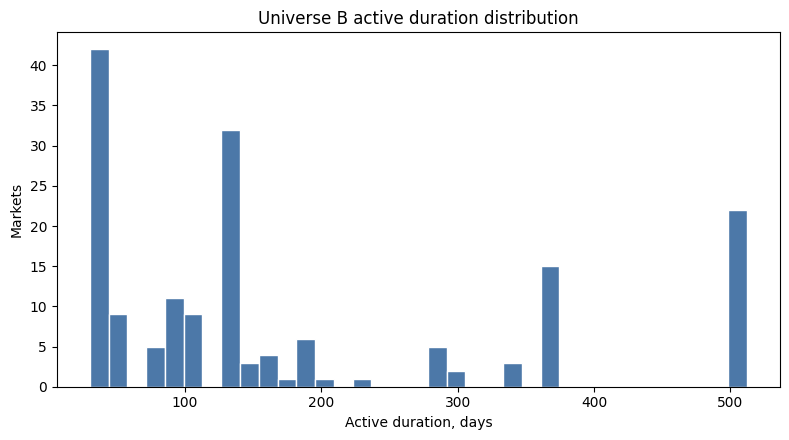

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
days = lifetimes["active_duration_hours"] / 24
ax.hist(days.dropna(), bins=35, color="#4C78A8", edgecolor="white")
ax.set_title("Universe B active duration distribution")
ax.set_xlabel("Active duration, days")
ax.set_ylabel("Markets")
plt.tight_layout()
plt.savefig(FIGURES / "01_duration_histogram.png", dpi=160, bbox_inches="tight")
plt.show()

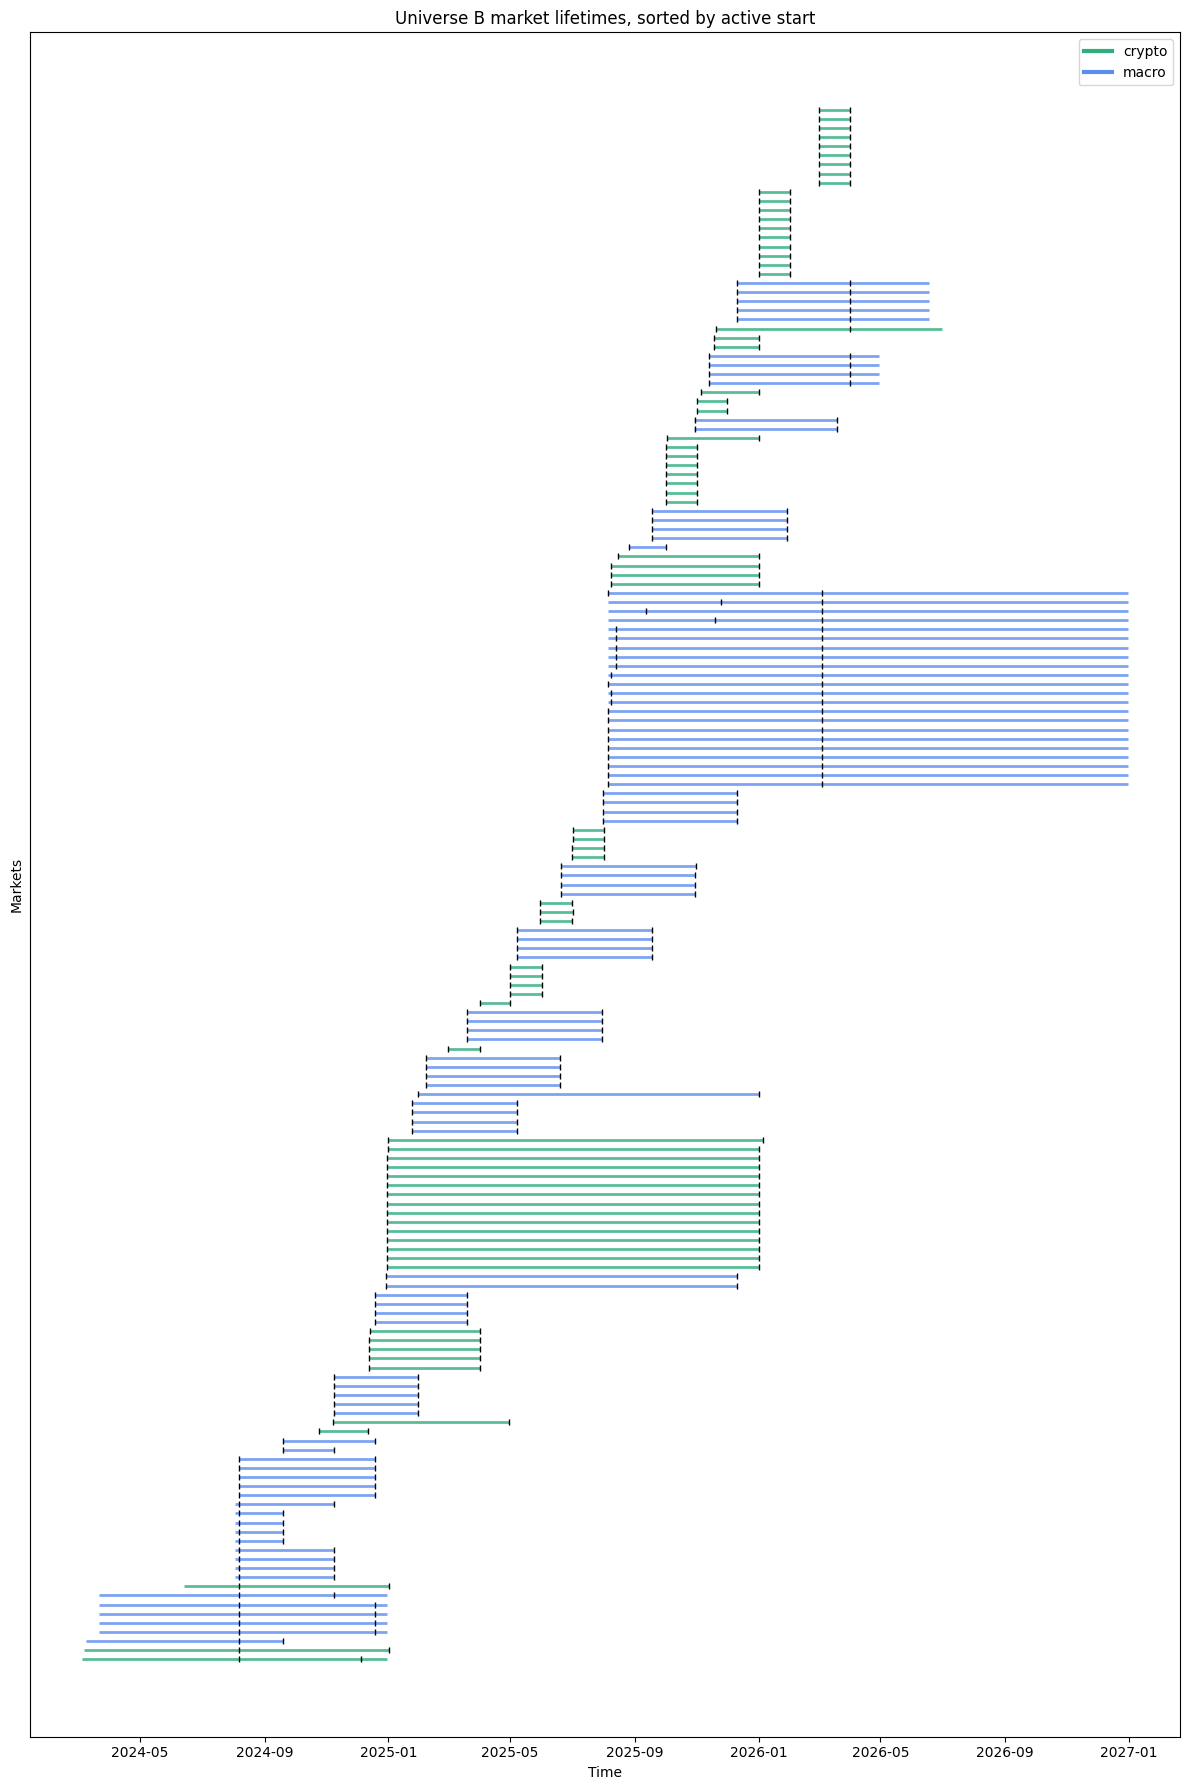

In [5]:
timeline = lifetimes.sort_values(["active_start", "active_end"]).reset_index(drop=True)
colors = timeline["broad_domain"].map({"crypto": "#2EAD7D", "macro": "#5B8DEF"}).fillna("#888888")
fig, ax = plt.subplots(figsize=(12, 18))
for y, row in timeline.iterrows():
    if pd.notna(row["active_start"]) and pd.notna(row["active_end"]):
        ax.hlines(y, row["active_start"], row["active_end"], color=colors.iloc[y], linewidth=2.0, alpha=0.8)
        if pd.notna(row["first_observed_timestamp"]):
            ax.plot(row["first_observed_timestamp"], y, marker="|", color="black", markersize=5)
        if pd.notna(row["last_observed_timestamp"]):
            ax.plot(row["last_observed_timestamp"], y, marker="|", color="black", markersize=5)
ax.set_title("Universe B market lifetimes, sorted by active start")
ax.set_xlabel("Time")
ax.set_ylabel("Markets")
ax.set_yticks([])
for label, color in {"crypto": "#2EAD7D", "macro": "#5B8DEF"}.items():
    ax.plot([], [], color=color, linewidth=3, label=label)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIGURES / "02_lifetime_timeline.png", dpi=160, bbox_inches="tight")
plt.show()

## Part 2: Pairwise Overlap Matrix

In [6]:
upper = overlap.to_numpy()[np.triu_indices_from(overlap.to_numpy(), k=1)]
upper = upper[np.isfinite(upper)]
pairwise_stats = pd.DataFrame([overlap_stats])
display(pairwise_stats)
print("Share of market pairs with zero overlap:", float((upper == 0).mean()))
print("Share of market pairs with overlap >= 0.10:", float((upper >= 0.10).mean()))
print("Share of market pairs with overlap >= 0.25:", float((upper >= 0.25).mean()))

,mean,median,min,max
0,0.010706,0.0,0.0,0.194969


Share of market pairs with zero overlap: 0.5795665634674922
Share of market pairs with overlap >= 0.10: 0.008118335053319574
Share of market pairs with overlap >= 0.25: 0.0


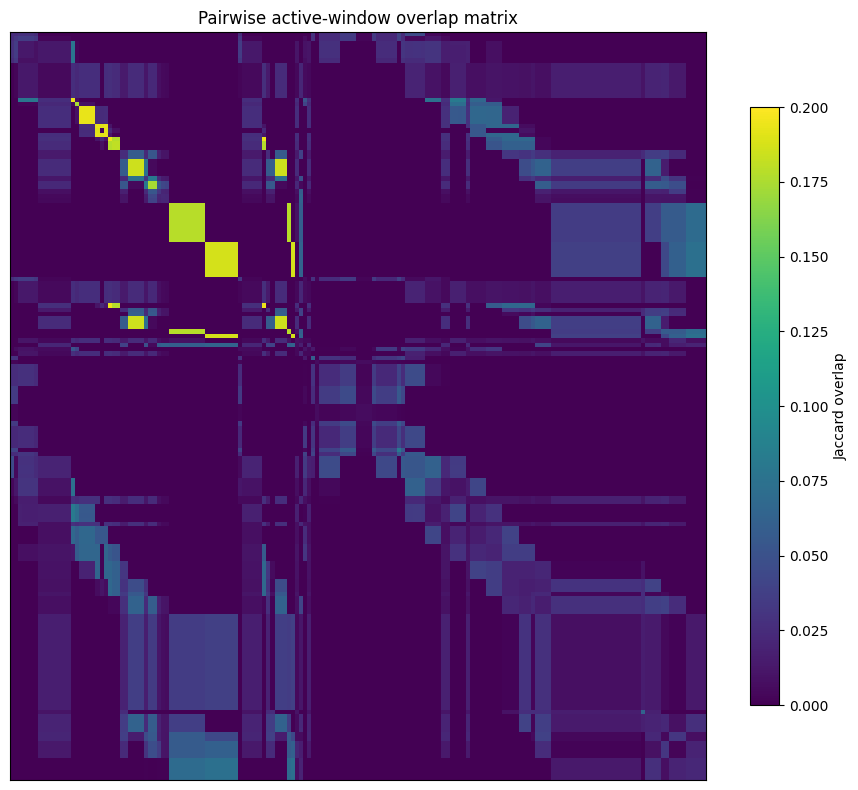

In [7]:
ordered_ids = lifetimes.sort_values(["broad_domain", "broad_family", "active_start"])["market_id"].tolist()
ordered_overlap = overlap.loc[ordered_ids, ordered_ids]
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(ordered_overlap.to_numpy(), vmin=0, vmax=max(0.20, float(np.nanmax(ordered_overlap.to_numpy()))), cmap="viridis", aspect="auto")
ax.set_title("Pairwise active-window overlap matrix")
ax.set_xticks([])
ax.set_yticks([])
plt.colorbar(im, ax=ax, shrink=0.8, label="Jaccard overlap")
plt.tight_layout()
plt.savefig(FIGURES / "03_overlap_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

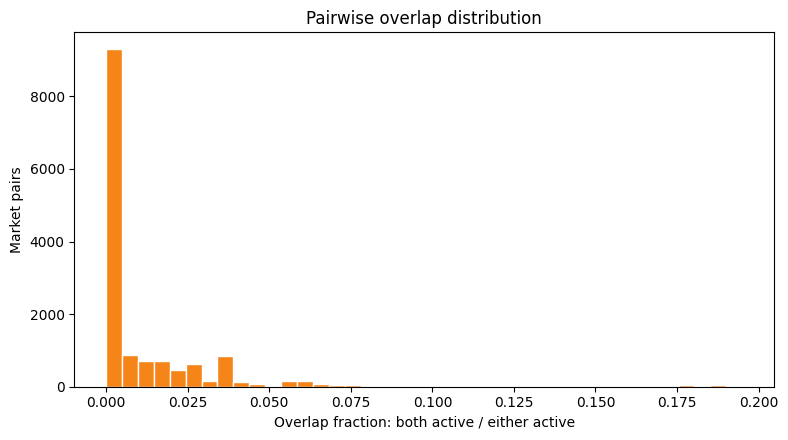

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(upper, bins=40, color="#F58518", edgecolor="white")
ax.set_title("Pairwise overlap distribution")
ax.set_xlabel("Overlap fraction: both active / either active")
ax.set_ylabel("Market pairs")
plt.tight_layout()
plt.savefig(FIGURES / "04_overlap_histogram.png", dpi=160, bbox_inches="tight")
plt.show()

## Part 3: Missingness Decomposition

,value
total_cells,2.473344e+06
observed_filled_cells,5.329790e+05
raw_observed_cells,5.305870e+05
missing_cells,1.940365e+06
overall_missingness,7.845108e-01
structural_missing_cells,1.915462e+06
data_missing_cells,2.490300e+04
active_raw_missing_cells,2.729500e+04
structural_missing_fraction_of_all,7.744422e-01
data_missing_fraction_of_all,1.006855e-02


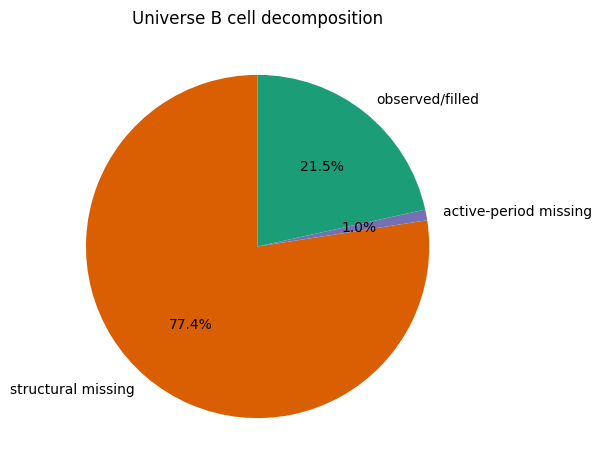

In [9]:
missingness_table = pd.DataFrame([missingness]).T.rename(columns={0: "value"})
display(missingness_table)

pie_values = [missingness["structural_missing_cells"], missingness["data_missing_cells"], missingness["observed_filled_cells"]]
pie_labels = ["structural missing", "active-period missing", "observed/filled"]
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(pie_values, labels=pie_labels, autopct="%1.1f%%", startangle=90, colors=["#D95F02", "#7570B3", "#1B9E77"])
ax.set_title("Universe B cell decomposition")
plt.tight_layout()
plt.savefig(FIGURES / "05_missingness_decomposition.png", dpi=160, bbox_inches="tight")
plt.show()

## Part 4: Overlap-Constrained Universes

In [10]:
display(candidates[[
    "universe", "market_count", "yes_rate", "no_rate", "class_entropy", "panel_missingness",
    "median_active_markets", "mean_pairwise_overlap", "median_pairwise_overlap",
    "mean_abs_pairwise_corr", "median_abs_pairwise_corr"
]])

avg_overlap = lifetimes["average_pairwise_overlap"].dropna()
threshold_counts = pd.DataFrame({
    "threshold": [0.25, 0.40, 0.50],
    "markets_kept": [(avg_overlap >= t).sum() for t in [0.25, 0.40, 0.50]],
})
display(threshold_counts)

,universe,market_count,yes_rate,no_rate,class_entropy,panel_missingness,median_active_markets,mean_pairwise_overlap,median_pairwise_overlap,mean_abs_pairwise_corr,median_abs_pairwise_corr
0,Universe B,171,0.111111,0.888889,0.503258,0.784511,34.0,0.010706,0.0,0.415976,0.379139
1,Universe B-25,0,NaN,NaN,0.000000,NaN,0.0,NaN,NaN,NaN,NaN
2,Universe B-40,0,NaN,NaN,0.000000,NaN,0.0,NaN,NaN,NaN,NaN
3,Universe B-50,0,NaN,NaN,0.000000,NaN,0.0,NaN,NaN,NaN,NaN


,threshold,markets_kept
0,0.25,0
1,0.40,0
2,0.50,0


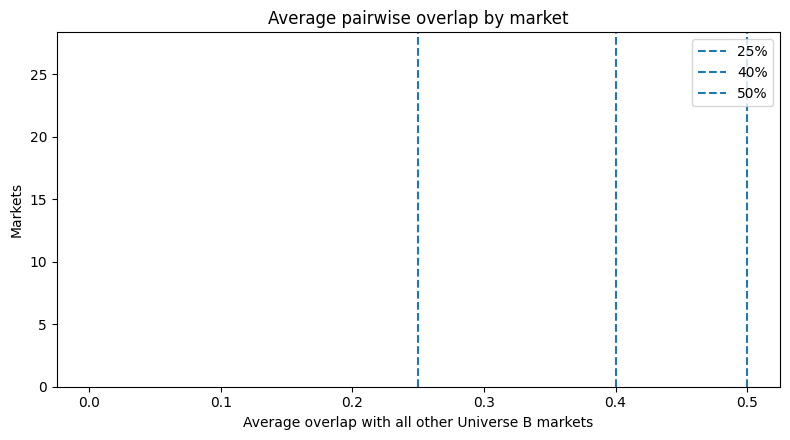

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(avg_overlap, bins=30, color="#54A24B", edgecolor="white")
for threshold in [0.25, 0.40, 0.50]:
    ax.axvline(threshold, linestyle="--", linewidth=1.5, label=f"{int(threshold*100)}%")
ax.set_title("Average pairwise overlap by market")
ax.set_xlabel("Average overlap with all other Universe B markets")
ax.set_ylabel("Markets")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "06_average_overlap_histogram.png", dpi=160, bbox_inches="tight")
plt.show()

## Part 5: PCA Compressibility

,universe,market_count,panel_missingness,mean_abs_pairwise_corr,pc_85,pc_90,pc_95,pc1_variance,pc2_cumulative_variance,pc5_cumulative_variance
0,Universe B,171,0.784511,0.415976,40.0,49.0,64.0,0.090322,0.1564,0.30264
1,Universe B-25,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Universe B-40,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Universe B-50,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


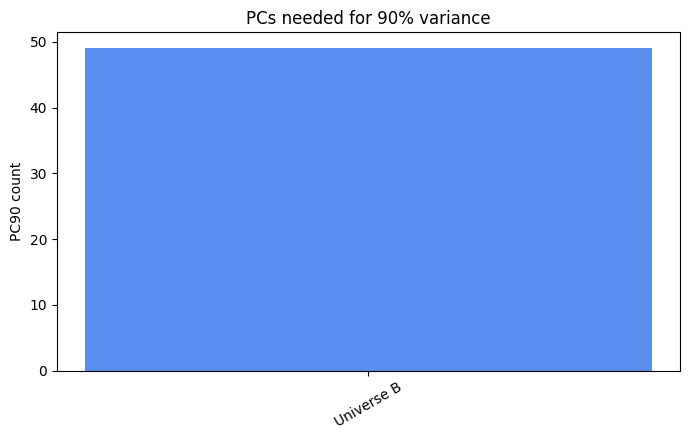

In [12]:
display(candidates[[
    "universe", "market_count", "panel_missingness", "mean_abs_pairwise_corr",
    "pc_85", "pc_90", "pc_95", "pc1_variance", "pc2_cumulative_variance", "pc5_cumulative_variance"
]])

fig, ax = plt.subplots(figsize=(7, 4.5))
plot = candidates.dropna(subset=["pc_90"])
ax.bar(plot["universe"], plot["pc_90"], color="#5B8DEF")
ax.set_title("PCs needed for 90% variance")
ax.set_ylabel("PC90 count")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIGURES / "07_pc90_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## Part 6: Recommendation Summary

In [13]:
summary_text = (PROCESSED / "overlap_analysis_summary.md").read_text(encoding="utf-8")
print(summary_text)

OVERLAP ANALYSIS SUMMARY

Original Universe B:

- market count: 171
- missingness: 0.785
- structural missingness: 0.774 of all cells, 0.987 of missing cells
- data missingness after active forward-fill: 0.010 of all cells, 0.013 of missing cells
- raw active-period sparsity before forward-fill: 0.049 of active cells

Overlap statistics:

- mean overlap: 0.011
- median overlap: 0.000
- minimum overlap: 0.000
- maximum overlap: 0.195

Candidate universes:

| universe | market_count | yes_rate | class_entropy | panel_missingness | median_active_markets | mean_pairwise_overlap | pc_90 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Universe B | 171 | 0.111 | 0.503 | 0.785 | 34.000 | 0.011 | 49.000 |
| Universe B-25 | 0 |  | 0.000 |  | 0.000 |  |  |
| Universe B-40 | 0 |  | 0.000 |  | 0.000 |  |  |
| Universe B-50 | 0 |  | 0.000 |  | 0.000 |  |  |

Interpretation:

- The 78.5% panel missingness is mostly structural.
- Active-period data gaps are small relative to structural gaps; the